**Ders 19 Öneri sistemleri**

Bu çalışmada gerçek veri seti üzerinden film öneri sistemi geliştirilmektedir.

- Kullanıcı-film puan matrisi oluşturacağız
- İçerik tabanlı filtreleme (Content-Based Filtering) uygulayacağız
- İşbirlikçi filtreleme (Collaborative Filtering) uygulayacağız
- Kosinüs benzerliği ile kullanıcı bazlı öneriler yapacağız
- "Bu filmi izleyen şunu da izledi" mantığını kodlayacağız


1. Kütüphanelerin Yüklenmesi
| Kütüphane | Amacı |
|-----------|-------|
| `matplotlib` | Grafik ve görselleştirme |
| `numpy` | Sayısal hesaplamalar ve dizi işlemleri |
| `pandas` | Veri çerçeveleri (DataFrame) ile veri analizi |
| `seaborn` | İstatistiksel görselleştirme (Matplotlib üzerine kurulu) |
| `sklearn` | Makine öğrenmesi algoritmaları ve araçları |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
np.random.seed(42)
plt.rcParams['figure.figsize']=(12,6)

## 2. Gerçek MovieLens Verisini Yükleme

**MovieLens Small Dataset** — GroupLens tarafından toplanan gerçek film değerlendirmeleri. 100.000+ değerlendirme, 600+ kullanıcı, 9.000+ film.

**Kaynak:** [MovieLens](https://grouplens.org/datasets/movielens/) | [Kaggle](https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset)

In [2]:
# MovieLens Small Dataset (gerçek veri)
import zipfile, io, urllib.request
print('Veri seti indiriliyor...')
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
resp=urllib.request.urlopen(url) # HTTP response nesnesi
z=zipfile.ZipFile(io.BytesIO(resp.read())) # Byte olarak ZIP dosyasını aç
z

Veri seti indiriliyor...


<zipfile.ZipFile file=<_io.BytesIO object at 0x7c74cfb3d800> mode='r'>

In [3]:
ratings=pd.read_csv(z.open('ml-latest-small/ratings.csv')) # iki ayrı dosya okunarak ayrı df'lere yükleniyor.
movies=pd.read_csv(z.open('ml-latest-small/movies.csv'))

In [4]:
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [5]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [6]:
# ortak alan (movieid) ile iki df birleştirilir
df=ratings.merge(movies, how='left', on='movieId')
df
#

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100831,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller
100832,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller
100833,610,168250,5.0,1494273047,Get Out (2017),Horror
100834,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi


In [7]:
print(f"Toplam değerlendirme (rating): {df.shape[0]}")
print(f"Toplam film (movie): {df['movieId'].nunique()}")
print(f"Toplam kullanıcı (user): {df['userId'].nunique()}")
print(f"Puan Dağılımı")
print(df['rating'].value_counts().sort_index())
print("Rastgele 10 film")
print(df.sample(10, random_state=42)['title'].values)

Toplam değerlendirme (rating): 100836
Toplam film (movie): 9724
Toplam kullanıcı (user): 610
Puan Dağılımı
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64
Rastgele 10 film
['Robin Hood (2010)' 'In the Line of Fire (1993)' 'Point Break (1991)'
 'Who Framed Roger Rabbit? (1988)' 'Hunt for Red October, The (1990)'
 'Lord of Illusions (1995)' '300 (2007)'
 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)'
 "Charlie's Angels: Full Throttle (2003)"
 'Anchorman: The Legend of Ron Burgundy (2004)']


<Axes: xlabel='rating'>

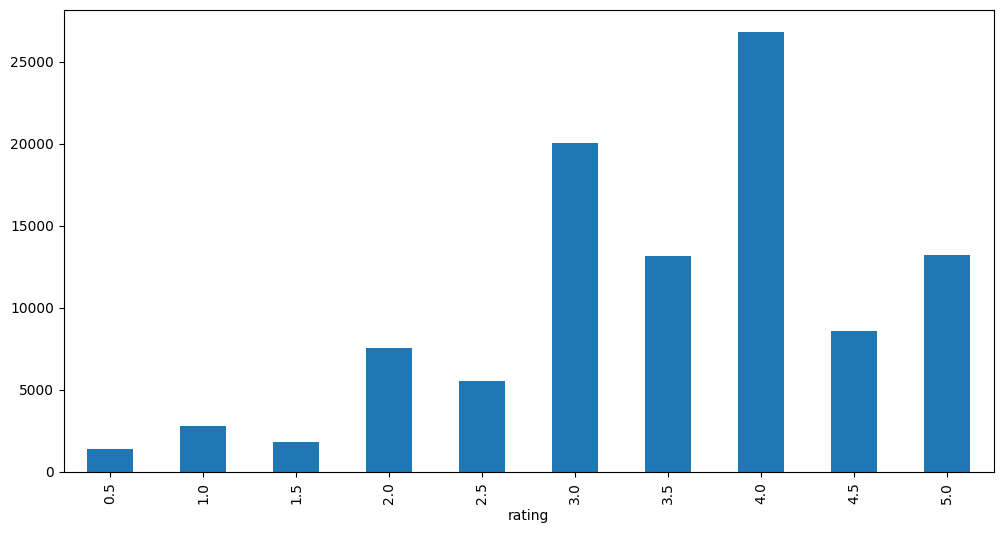

In [8]:
df['rating'].value_counts().sort_index().plot(kind='bar')

In [9]:
#Ortalama rating
df['rating'].mean()

np.float64(3.501556983616962)

### Öneri Sistemi

Kullanıcı-ürün matrisi ve benzerlik hesabı ile öneri sistemi kuruyoruz. Cosine benzerliği, iki vektör arasındaki açıya dayalı bir benzerlik ölçüsüdür.

1. Veriyi Hazırlama (Mutfak Hazırlığı)
İlk olarak MovieLens adındaki devasa bir kütüphaneden yaklaşık 100.000 film puanını aldık.

Nasıl Yapıldı?: pandas kütüphanesi ile kullanıcıların hangi filme kaç puan verdiğini ve o filmin türlerini içeren tabloları birleştirdik.
Pivot Tablo: 'Hangi kullanıcı, hangi filme ne puan verdi?' sorusunun cevabı olan dev bir matris (satırlarda kullanıcılar, sütunlarda filmler) oluşturduk.

In [10]:
#Kullanıcı-film puan matrisi hazırlama (pivot tablo)
# En çok değerlendirilen ilk 500 filmi seçelim (performasn için)
popular_movies=df['movieId'].value_counts().head(500).index
popular_movies

Index([  356,   318,   296,   593,  2571,   260,   480,   110,   589,   527,
       ...
        1994,   112,  1396,  5060, 64614,   802,  1884,  2076,  2002,    44],
      dtype='int64', name='movieId', length=500)

popüler film listesi doğrudan kullanıcılara öneri olarak sunulabilmektedir.

Yine yorum * rating de skor olarak kullanılabilmektedir.

Bunun dışında farklı popülerlik hesaplamaları yer almaktadır.

Haftanın, ayın, yılın en çok izlenenleri gibi


In [11]:
df_popular=df[df['movieId'].isin(popular_movies)]
df_popular

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100673,610,109487,3.5,1493845041,Interstellar (2014),Sci-Fi|IMAX
100701,610,112852,4.5,1493845402,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi
100737,610,122882,5.0,1493845444,Mad Max: Fury Road (2015),Action|Adventure|Sci-Fi|Thriller
100742,610,122904,3.0,1493845981,Deadpool (2016),Action|Adventure|Comedy|Sci-Fi


In [12]:
#Pivot Tabloda satırlar:kullanıcılar sütunlar da : film_id değerler de rating puanları
user_movie_matrix=df_popular.pivot_table(index='userId',
                                         columns='title',
                                         values='rating')
user_movie_matrix

title,10 Things I Hate About You (1999),101 Dalmatians (1996),12 Angry Men (1957),2001: A Space Odyssey (1968),28 Days Later (2002),300 (2007),"40-Year-Old Virgin, The (2005)",50 First Dates (2004),A.I. Artificial Intelligence (2001),"Abyss, The (1989)",...,Willy Wonka & the Chocolate Factory (1971),"Wizard of Oz, The (1939)","Wolf of Wall Street, The (2013)",X-Men (2000),X-Men: The Last Stand (2006),X2: X-Men United (2003),You've Got Mail (1998),Young Frankenstein (1974),Zombieland (2009),Zoolander (2001)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,5.0,5.0,NaN,5.0,NaN,NaN,NaN,5.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN
4,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,3.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.5,3.5,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,3.0,3.5,5.0,NaN,NaN,4.5,3.0,...,3.5,2.5,NaN,4.0,4.0,4.0,NaN,NaN,NaN,3.0


In [13]:
user_movie_matrix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 1 to 610
Columns: 500 entries, 10 Things I Hate About You (1999) to Zoolander (2001)
dtypes: float64(500)
memory usage: 2.3 MB


In [14]:
print(f"Kullanıcı-Film Matrisi: {user_movie_matrix.shape}")
print(f"Dolumluk oranı: {user_movie_matrix.notna().sum().sum() / user_movie_matrix.size:.2%}")
print(f"\nİlk 5 kullanıcı, 5 film:")
user_movie_matrix.iloc[:5, :5]

Kullanıcı-Film Matrisi: (607, 500)
Dolumluk oranı: 14.41%

İlk 5 kullanıcı, 5 film:


title,10 Things I Hate About You (1999),101 Dalmatians (1996),12 Angry Men (1957),2001: A Space Odyssey (1968),28 Days Later (2002)
userId,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,5.0,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


### Dağılım Görselleştirmesi

Aşağıdaki grafikte verinin dağılımını histogram ile inceliyoruz. Dağılımın şekli (normal, çarpık, bimodal) hangi istatistiksel yöntemlerin uygulanabileceğini belirler.

Text(0, 0.5, 'Sayı')

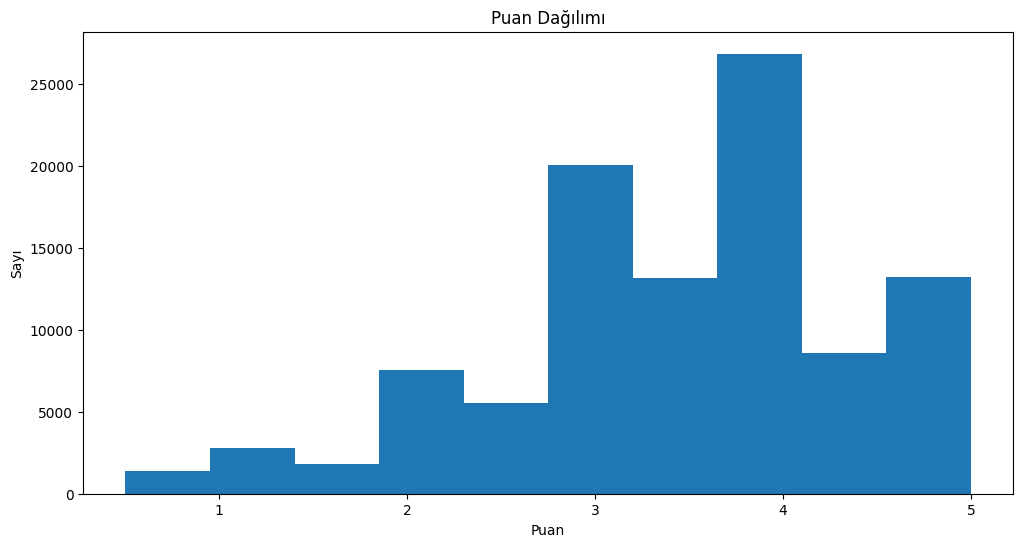

In [15]:
#puan dağılımı df['rating']
plt.hist(df['rating'])
plt.title("Puan Dağılımı")
plt.xlabel("Puan")
plt.ylabel("Sayı")

## 3. İçerik Tabanlı Filtreleme (Content-Based Filtering)

Filmlerin tür özelliklerine göre benzerlik hesaplıyoruz. Eğer bir kullanıcı bir filmi beğendiyse, benzer türdeki filmler önerilir.

2. İçerik Tabanlı Öneri (Tür Benzerliği)
'Eğer Aksiyon ve Bilim Kurgu seviyorsan, sana başka bir Aksiyon ve Bilim Kurgu filmi önerelim' mantığıdır.

Nasıl Yapıldı?: Filmlerin türlerini (Komedi, Korku vb.) bilgisayarın anlayacağı 0 ve 1 sayılarına dönüştürdük.
Kosinüs Benzerliği: Bu sayısal veriler arasındaki 'açıyı' hesapladık. Açı ne kadar darsa (1.00'e yakınsa), filmler tür olarak o kadar benzerdir.

In [16]:
df[df['movieId'].isin (popular_movies)] #500 popüler film listesi

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100673,610,109487,3.5,1493845041,Interstellar (2014),Sci-Fi|IMAX
100701,610,112852,4.5,1493845402,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi
100737,610,122882,5.0,1493845444,Mad Max: Fury Road (2015),Action|Adventure|Sci-Fi|Thriller
100742,610,122904,3.0,1493845981,Deadpool (2016),Action|Adventure|Comedy|Sci-Fi


In [17]:
#performans için popüler filmlerle sıralayalım
films_df=movies[movies['movieId'].isin(popular_movies)].set_index('title')
# 1. türleri sayısallaştır ve film isimlerini index yap
genres_split=films_df['genres'].str.get_dummies(sep='|')
genres_split

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
title,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Jumanji (1995),0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Grumpier Old Men (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Heat (1995),1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guardians of the Galaxy (2014),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
The Imitation Game (2014),0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
Mad Max: Fury Road (2015),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


In [18]:
genres_split.columns

Index(['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')

In [19]:
#Matrisi popüler filmlerle sınırla
genre_matrix=genres_split.loc[films_df.index]
film_names=films_df.index
len(film_names)

500

In [21]:
#Filmler arası cos Benzerlik hesaplaması
film_similarity=cosine_similarity(genre_matrix)
film_sim_df=pd.DataFrame(film_similarity, index=film_names, columns=film_names)
film_sim_df

title,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Father of the Bride Part II (1995),Heat (1995),Sabrina (1995),GoldenEye (1995),"American President, The (1995)",Casino (1995),Sense and Sensibility (1995),...,Skyfall (2012),Django Unchained (2012),"Wolf of Wall Street, The (2013)","Grand Budapest Hotel, The (2014)",Interstellar (2014),Guardians of the Galaxy (2014),The Imitation Game (2014),Mad Max: Fury Road (2015),Deadpool (2016),The Martian (2015)
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),1.000000,0.774597,0.316228,0.447214,0.000000,0.316228,0.258199,0.258199,0.000000,0.000000,...,0.223607,0.000000,0.258199,0.316228,0.000000,0.258199,0.000000,0.223607,0.447214,0.258199
Jumanji (1995),0.774597,1.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,...,0.288675,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.288675,0.288675,0.333333
Grumpier Old Men (1995),0.316228,0.000000,1.000000,0.707107,0.000000,1.000000,0.000000,0.816497,0.000000,0.500000,...,0.000000,0.000000,0.408248,0.500000,0.000000,0.000000,0.000000,0.000000,0.353553,0.000000
Father of the Bride Part II (1995),0.447214,0.000000,0.707107,1.000000,0.000000,0.707107,0.000000,0.577350,0.000000,0.000000,...,0.000000,0.000000,0.577350,0.707107,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
Heat (1995),0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.666667,0.000000,0.408248,0.000000,...,0.577350,0.333333,0.333333,0.000000,0.000000,0.333333,0.333333,0.577350,0.288675,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guardians of the Galaxy (2014),0.258199,0.333333,0.000000,0.000000,0.333333,0.000000,0.666667,0.000000,0.000000,0.000000,...,0.577350,0.333333,0.000000,0.000000,0.408248,1.000000,0.000000,0.866025,0.866025,0.666667
The Imitation Game (2014),0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.333333,0.333333,0.408248,0.408248,...,0.288675,0.333333,0.333333,0.408248,0.000000,0.000000,1.000000,0.288675,0.000000,0.333333
Mad Max: Fury Road (2015),0.223607,0.288675,0.000000,0.000000,0.577350,0.000000,0.866025,0.000000,0.000000,0.000000,...,0.750000,0.288675,0.000000,0.000000,0.353553,0.866025,0.288675,1.000000,0.750000,0.577350


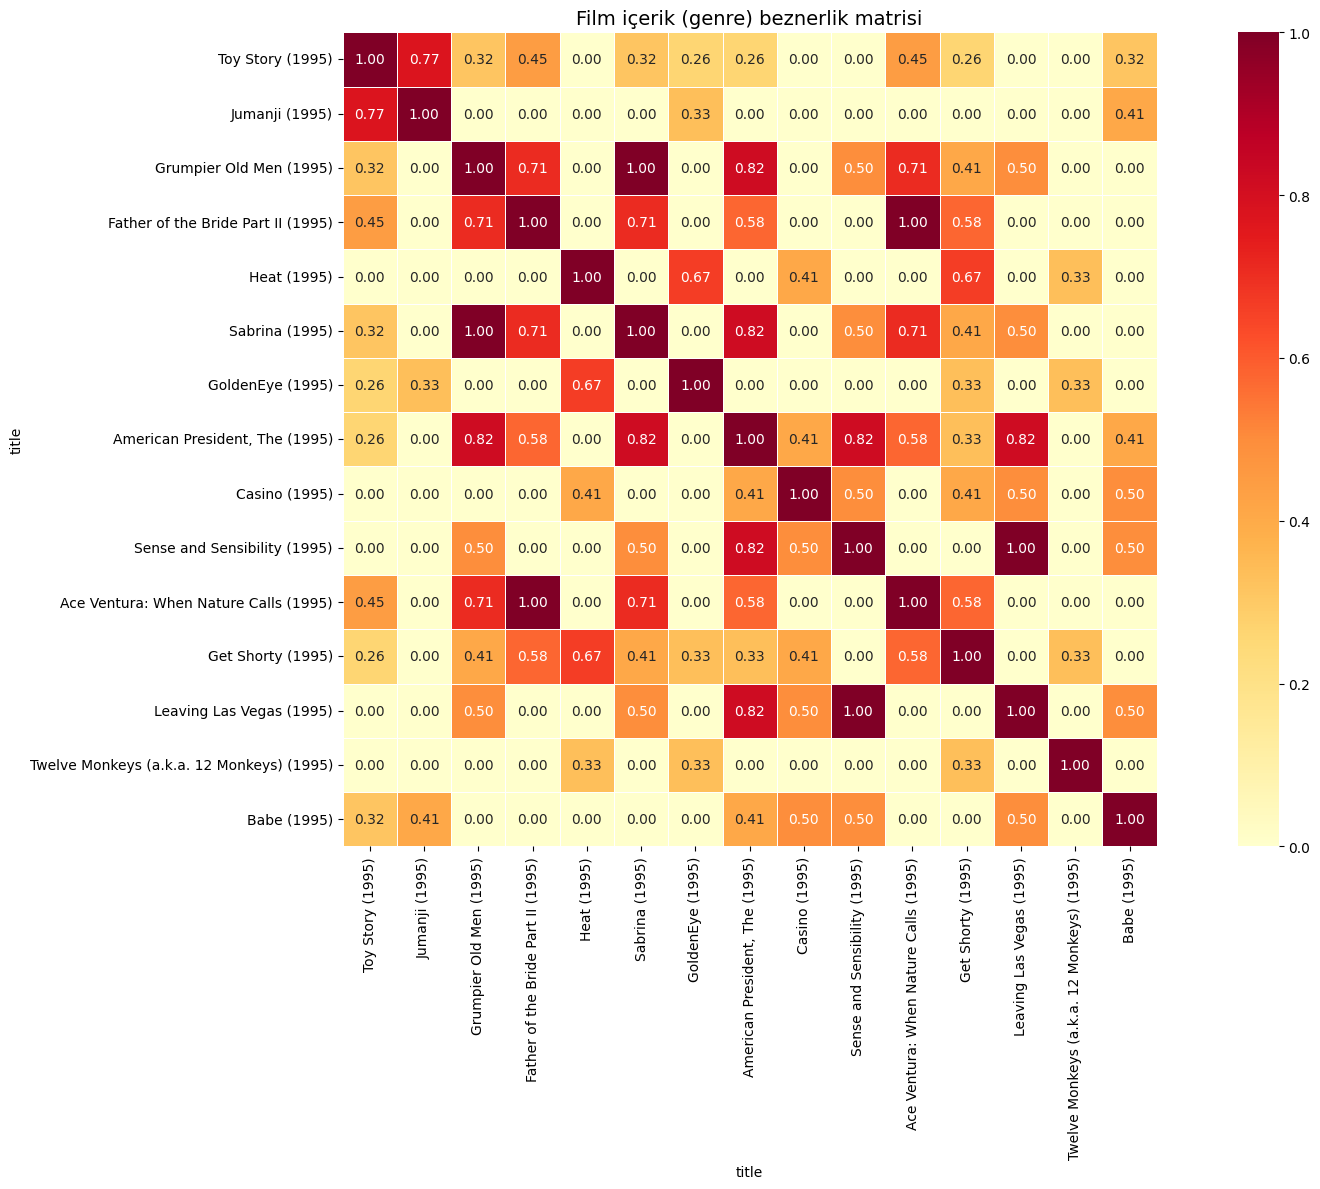

In [22]:
# Heat Map Isı haritası
plt.figure(figsize=(18,12))
sns.heatmap(film_sim_df.iloc[:15,:15],
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            square=True,
            linewidths=.5);
plt.title("Film içerik (genre) benzerlik matrisi", fontsize=14)
plt.tight_layout()
plt.show()

### İçerik Tabanlı Öneri Fonksiyonu

Aşağıda bir film adı verip, tür benzerliğine göre en yakın filmleri bulan fonksiyon tanımlanmaktadır.

In [23]:
def content_based_recommend(film_adi, n=5):
    """Verilen filme benzer filmleri önerir (içerik tabanlı)."""
    if film_adi not in film_sim_df.index:
        print(f"'{film_adi}' bulunamadı!")
        return None

    similarities = film_sim_df[film_adi].drop(film_adi).sort_values(ascending=False)
    top_n = similarities.head(n)

    print(f"\n'{film_adi}' filmine benzer filmler:")
    print("=" * 50)
    for film, score in top_n.items():
        turler = films_df.loc[film]
        tur_listesi = ', '.join(turler[turler == 1].index)
        print(f"  {film} (Benzerlik: {score:.2f}) - Türler: {tur_listesi}")

    return top_n

content_based_recommend('Toy Story (1995)', n=5)


'Toy Story (1995)' filmine benzer filmler:
  Monsters, Inc. (2001) (Benzerlik: 1.00) - Türler: 
  Toy Story 2 (1999) (Benzerlik: 1.00) - Türler: 
  Toy Story 3 (2010) (Benzerlik: 0.91) - Türler: 
  Shrek (2001) (Benzerlik: 0.91) - Türler: 
  Space Jam (1996) (Benzerlik: 0.91) - Türler: 


,Toy Story (1995)
title,
"Monsters, Inc. (2001)",1.000000
Toy Story 2 (1999),1.000000
Toy Story 3 (2010),0.912871
Shrek (2001),0.912871
Space Jam (1996),0.912871


# Standart film arası yaparak filmin tam ismini bul.

In [24]:
search_term = input("Aramak istediğiniz film adını girin: ")

# Popüler filmler içinden (df_popular) başlıkta arama yapma
# str.contains ile büyük-küçük harf duyarsız (case=False) filtreleme yapıyoruz
results = df_popular[df_popular['title'].str.contains(search_term, case=False, na=False, regex=False)]

# Sadece benzersiz film isimlerini ve türlerini listeleyelim
unique_results = results[['title', 'genres']].drop_duplicates()

if unique_results.empty:
    print(f"'{search_term}' kelimesini içeren popüler bir film bulunamadı.")
else:
    print(f"'{search_term}' içeren sonuçlar:")
    display(unique_results)

Aramak istediğiniz film adını girin: Matrix, The (1999)


/tmp/ipykernel_43187/404480736.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  results = df_popular[df_popular['title'].str.contains(search_term, case=False, na=False)]


'Matrix, The (1999)' kelimesini içeren popüler bir film bulunamadı.


In [25]:
content_based_recommend('Matrix, The (1999)', n=5)


'Matrix, The (1999)' filmine benzer filmler:
  Johnny Mnemonic (1995) (Benzerlik: 1.00) - Türler: 
  X-Men: The Last Stand (2006) (Benzerlik: 1.00) - Türler: 
  Blade Runner (1982) (Benzerlik: 1.00) - Türler: 
  Predator (1987) (Benzerlik: 1.00) - Türler: 
  Terminator, The (1984) (Benzerlik: 1.00) - Türler: 


,"Matrix, The (1999)"
title,
Johnny Mnemonic (1995),1.0
X-Men: The Last Stand (2006),1.0
Blade Runner (1982),1.0
Predator (1987),1.0
"Terminator, The (1984)",1.0


In [26]:
content_based_recommend('Matrix Reloaded, The (2003)', n=5)


'Matrix Reloaded, The (2003)' filmine benzer filmler:
  Iron Man 2 (2010) (Benzerlik: 1.00) - Türler: 
  Matrix Revolutions, The (2003) (Benzerlik: 1.00) - Türler: 
  Total Recall (1990) (Benzerlik: 0.89) - Türler: 
  V for Vendetta (2006) (Benzerlik: 0.89) - Türler: 
  I, Robot (2004) (Benzerlik: 0.89) - Türler: 


,"Matrix Reloaded, The (2003)"
title,
Iron Man 2 (2010),1.000000
"Matrix Revolutions, The (2003)",1.000000
Total Recall (1990),0.894427
V for Vendetta (2006),0.894427
"I, Robot (2004)",0.894427


In [27]:
!pip install -q gradio

In [33]:
import gradio as gr

def gradio_recommend(film_adi, n_count):
    # Mevcut fonksiyonu kullanarak sonuçları alalım
    # Fonksiyon print yaptığı için çıktıları yakalamak yerine doğrudan benzerlikleri alıp formatlıyoruz
    if film_adi not in film_sim_df.index:
        return "Film bulunamadı."

    similarities = film_sim_df[film_adi].drop(film_adi).sort_values(ascending=False)
    top_n = similarities.head(int(n_count))

    output_text = f"### '{film_adi}' Benzeri Öneriler:\n"
    for film, score in top_n.items():
        turler = films_df.loc[film]['genres']
        output_text += f"- **{film}** (Benzerlik: {score:.2f}) - Türler: {turler}\n"

    return output_text

# Popüler film listesini alfabetik sıralayarak dropdown için hazırlayalım
popular_titles = sorted(film_sim_df.index.tolist())

interface = gr.Interface(
    fn=gradio_recommend,
    inputs=[
        gr.Dropdown(choices=popular_titles, label="Bir Film Seçin", info="Sadece 500 popüler film arasından seçim yapabilirsiniz."),
        gr.Slider(minimum=1, maximum=20, step=1, value=5, label="Öneri Sayısı (n)")
    ],
    outputs=gr.Markdown(label="Öneriler"),
    title="Film Öneri Sistemi (İçerik Tabanlı)",
    description="Popüler bir film seçin ve tür benzerliğine göre önerileri görün."
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e814d40167b9620e70.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 

## 4. İşbirlikçi Filtreleme (Collaborative Filtering)

### Kavram Açıklaması

İşbirlikçi filtreleme iki ana yaklaşım içerir:

1. **Kullanıcı Tabanlı (User-Based)**: Benzer zevklere sahip kullanıcılar bulunur. "Senin gibi kullanıcılar şunu da beğendi."

2. **Öğe Tabanlı (Item-Based)**: Benzer puanlama örüntüsüne sahip filmler bulunur. "Bu filmi beğenenler şunu da beğendi."

Biz burada **Kullanıcı Tabanlı** yaklaşımı uygulayacağız.

3. İşbirlikçi Filtreleme (Ortak Zevkler)
'Zevkleri sana benzeyen insanlar neler izlemiş?' sorusuna yanıt arar.

Nasıl Yapıldı?: Senin verdiğin puanların dizilimi ile diğer 600+ kullanıcının puanlarını karşılaştırdık.
Tahmin: Sana benzeyen 5 kişiyi bulduk. Onların yüksek puan verip senin henüz izlemediğin filmleri belirledik ve sana bu filmlerin 'tahmini puanını' sunduk.

In [29]:
# ⚠️ KRİTİK NOT: NaN değerleri 0 ile doldurmak YANLIŞ bir yaklaşımdır!
# NaN = "bu filmi izlemedi" anlamına gelir, 0 ise "en düşük puan verdi" demektir.
# Doğru yaklaşım: Kullanıcının ortalama puanını çıkararak merkezleme yapmak.

# Yanlış yöntem (eğitim amaçlı gösteriliyor):
# ratings_filled = user_movie_matrix.fillna(0)

# Doğru yöntem: Ortalama merkezli doldurma
user_means = user_movie_matrix.mean(axis=1)  # Her kullanıcının ortalama puanı
ratings_centered = user_movie_matrix.sub(user_means, axis=0)  # Ortalamayı çıkar
ratings_filled = ratings_centered.fillna(0)  # Şimdi 0 = "nötr/bilgi yok" anlamına gelir

print("✅ Ortalama merkezli doldurma yapıldı.")
print(f"Örnek: Kullanıcı 1'in ortalama puanı: {user_means.iloc[0]:.2f}")
print(f"Merkezleme sonrası bir filmin değeri: orijinal puan - {user_means.iloc[0]:.2f}")
ratings_filled


title,10 Things I Hate About You (1999),101 Dalmatians (1996),12 Angry Men (1957),2001: A Space Odyssey (1968),28 Days Later (2002),300 (2007),"40-Year-Old Virgin, The (2005)",50 First Dates (2004),A.I. Artificial Intelligence (2001),"Abyss, The (1989)",...,Willy Wonka & the Chocolate Factory (1971),"Wizard of Oz, The (1939)","Wolf of Wall Street, The (2013)",X-Men (2000),X-Men: The Last Stand (2006),X2: X-Men United (2003),You've Got Mail (1998),Young Frankenstein (1974),Zombieland (2009),Zoolander (2001)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,5.0,5.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
4,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,3.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.5,3.5,0.0,0.0
607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
608,0.0,0.0,0.0,3.0,3.5,5.0,0.0,0.0,4.5,3.0,...,3.5,2.5,0.0,4.0,4.0,4.0,0.0,0.0,0.0,3.0


In [30]:
#kullanıcılar arası kosinüs benzerliği
user_similarity=cosine_similarity(ratings_filled)
user_similarity

array([[1.        , 0.0500123 , 0.13448567, ..., 0.4755423 , 0.15675369,
        0.33629946],
       [0.0500123 , 1.        , 0.        , ..., 0.08015854, 0.04587099,
        0.22318358],
       [0.13448567, 0.        , 1.        , ..., 0.08380949, 0.        ,
        0.01231081],
       ...,
       [0.4755423 , 0.08015854, 0.08380949, ..., 1.        , 0.21634   ,
        0.60230622],
       [0.15675369, 0.04587099, 0.        , ..., 0.21634   , 1.        ,
        0.13196771],
       [0.33629946, 0.22318358, 0.01231081, ..., 0.60230622, 0.13196771,
        1.        ]])

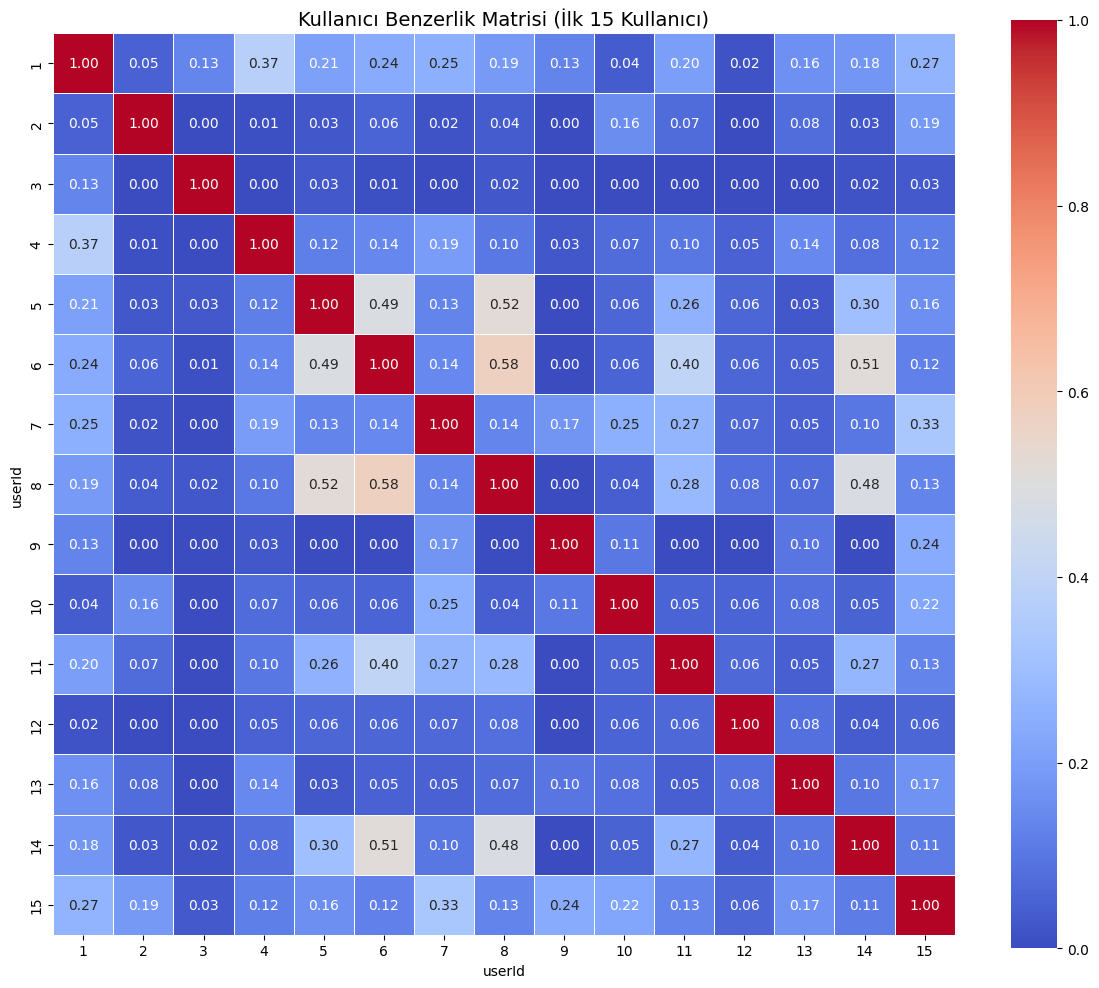

In [31]:
# user_names yerine matrisin indekslerini kullanıyoruz
user_sim_df = pd.DataFrame(user_similarity, index=user_movie_matrix.index, columns=user_movie_matrix.index)

plt.figure(figsize=(12, 10))
sns.heatmap(user_sim_df.iloc[:15, :15], annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=0, vmax=1)
plt.title('Kullanıcı Benzerlik Matrisi (İlk 15 Kullanıcı)', fontsize=14)
plt.tight_layout()
plt.show()

### Kullanıcı Tabanlı Öneri Fonksiyonu

Benzer kullanıcıların puanlarını ağırlıklı ortalamayla birleştirip, izlenmemiş filmler için tahmin üretir.

In [32]:
def user_based_recommend(user, n=5):
    """Kullanıcı tabanlı işbirlikçi filtreleme ile film önerir."""
    # ratings_df yerine user_movie_matrix kullanıyoruz
    if user not in user_movie_matrix.index:
        print(f"'{user}' bulunamadı!")
        return None

    # Kullanıcının izlemediği filmler
    unwatched = user_movie_matrix.loc[user][user_movie_matrix.loc[user].isna()].index

    if len(unwatched) == 0:
        print(f"{user} tüm filmleri izlemiş!")
        return None

    # Benzer kullanıcıları bul
    user_similarities = user_sim_df[user].drop(user).sort_values(ascending=False)
    top_similar_users = user_similarities.head(5).index

    # Benzer kullanıcıların puanlarını ağırlıklı ortalama ile hesapla
    predicted_scores = {}
    for film in unwatched:
        weighted_sum = 0
        similarity_sum = 0
        for sim_user in top_similar_users:
            rating = user_movie_matrix.loc[sim_user, film]
            if not np.isnan(rating):
                sim = user_sim_df.loc[user, sim_user]
                weighted_sum += sim * rating
                similarity_sum += sim
        if similarity_sum > 0:
            predicted_scores[film] = weighted_sum / similarity_sum

    # En yüksek tahmini puanlı filmleri sırala
    recommendations = pd.Series(predicted_scores).sort_values(ascending=False).head(n)

    print(f"\nUser ID {user} için önerilen filmler:")
    print("=" * 50)
    for film, score in recommendations.items():
        print(f"  {film} (Tahmini Puan: {score:.2f})")

    return recommendations

# Veri setindeki gerçek bir kullanıcı ID'si (örneğin 1) ile çağıralım
user_based_recommend(1, n=5)


User ID 1 için önerilen filmler:
  Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) (Tahmini Puan: 5.00)
  Requiem for a Dream (2000) (Tahmini Puan: 5.00)
  Kill Bill: Vol. 1 (2003) (Tahmini Puan: 5.00)
  North by Northwest (1959) (Tahmini Puan: 5.00)
  Lost in Translation (2003) (Tahmini Puan: 5.00)


,0
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",5.0
Requiem for a Dream (2000),5.0
Kill Bill: Vol. 1 (2003),5.0
North by Northwest (1959),5.0
Lost in Translation (2003),5.0


**4. 'Bu Filmi İzleyen Şunu da İzledi' Öğe Tabanlı**
Netflix veya Amazon'daki klasik öneri motorudur.

Nasıl Yapıldı?: Bir filmi (örneğin Matrix) izleyen tüm kullanıcıları listeledik. Sonra bu grubun ortaklaşa izlediği diğer popüler filmleri bulup bir 'popülerlik skoru' oluşturduk.
### Veri Ön İşleme

Modeli eğitmeden önce veriyi temizliyoruz ve dönüştürüyoruz. Eksik değerleri doldurma, kategorik değişkenleri sayıya çevirme ve ölçeklendirme bu adımın parçasıdır.

In [34]:
def also_watched(film_adi, n=5):
    """Verilen filmi izleyen kullanıcıların en çok izlediği diğer filmleri bulur.
    
    Skor = Lift tabanlı: P(B|A) / P(B) × ortalama puan
    Bu sayede popülerlik bias'ı azaltılır.
    """
    if film_adi not in user_movie_matrix.columns:
        print(f"\'{film_adi}\' bulunamadı! Lütfen tam adını kontrol edin.")
        return None

    total_users = len(user_movie_matrix)
    
    # Bu filmi izleyen kullanıcılar
    watchers = user_movie_matrix[film_adi].dropna().index
    n_watchers = len(watchers)

    if n_watchers == 0:
        print(f"\'{film_adi}\' filmini kimse izlememiş!")
        return None

    # Bu kullanıcıların izlediği diğer filmler
    other_films = user_movie_matrix.loc[watchers].drop(columns=[film_adi])

    # Lift hesabı: P(B|A) / P(B) — popülerlik bias'ını azaltır
    # P(B|A) = bu filmi izleyenler arasında B'yi izleyenlerin oranı
    # P(B)   = tüm kullanıcılar arasında B'yi izleyenlerin oranı
    watch_count_given_A = other_films.notna().sum()
    p_b_given_a = watch_count_given_A / n_watchers
    p_b = user_movie_matrix.drop(columns=[film_adi]).notna().sum() / total_users
    lift = p_b_given_a / p_b.clip(lower=0.01)  # sıfıra bölmeyi engelle

    avg_rating = other_films.mean()

    # Skor = lift × ortalama puan (en az 5 kişi izlemiş olmalı)
    valid = watch_count_given_A >= 5
    score = (lift * avg_rating).where(valid).dropna().sort_values(ascending=False).head(n)

    print(f"\n\'{film_adi}\' filmini izleyenler şunları da izledi:")
    print("=" * 60)
    for film, s in score.items():
        count = int(watch_count_given_A[film])
        avg = avg_rating[film]
        l = lift[film]
        if not np.isnan(avg):
            print(f"  {film}")
            print(f"    ({count} kişi izledi, Ort. Puan: {avg:.1f}, Lift: {l:.2f})")
    return score

# Örnek kullanım
also_watched('Matrix, The (1999)', n=5)



'Matrix, The (1999)' filmini izleyenler şunları da izledi:
  Shawshank Redemption, The (1994) (181 kişi izledi, Ort. Puan: 4.4)
  Forrest Gump (1994) (194 kişi izledi, Ort. Puan: 4.1)
  Pulp Fiction (1994) (178 kişi izledi, Ort. Puan: 4.4)
  Fight Club (1999) (180 kişi izledi, Ort. Puan: 4.3)
  Star Wars: Episode IV - A New Hope (1977) (183 kişi izledi, Ort. Puan: 4.2)


,0
title,
"Shawshank Redemption, The (1994)",796.5
Forrest Gump (1994),795.5
Pulp Fiction (1994),779.0
Fight Club (1999),772.0
Star Wars: Episode IV - A New Hope (1977),765.0


## 7. Basit Değerlendirme

Bilinen bir puanı gizleyip tahmin edebilir miyiz? Leave-one-out yöntemiyle test ediyoruz.

5. Başarı Testi (Doğruluk Kontrolü)
'Sistemimiz ne kadar iyi sallıyor?' diye kontrol ettik.

Nasıl Yapıldı?: Kullanıcıların zaten verdiği bazı puanları sistemden gizledik ve sistemden bunları tahmin etmesini istedik. Tahmin ile gerçek puan arasındaki farka (MAE) baktık. Ortalama 0.49 hata payı, 5 üzerinden yapılan bir puanlama için oldukça 'isabetli' sayılır.

In [35]:
# Geliştirilmiş değerlendirme: Daha büyük örneklem ile Leave-One-Out
import random
random.seed(42)

errors = []
n_test_users = min(50, len(user_movie_matrix))  # En az 50 kullanıcı test et
test_users = random.sample(list(user_movie_matrix.index), n_test_users)

for user in test_users:
    watched = user_movie_matrix.loc[user].dropna()
    if len(watched) < 5:  # En az 5 film izlemiş olmalı
        continue
    
    # Rastgele 3 film seç (her seferinde farklı)
    test_films = random.sample(list(watched.index), min(3, len(watched)))
    
    for film in test_films:
        actual = watched[film]
        
        # Benzer kullanıcılardan tahmin
        user_similarities = user_sim_df[user].drop(user).sort_values(ascending=False)
        top_similar = user_similarities.head(10).index  # 10 benzer kullanıcı
        
        weighted_sum = 0
        sim_sum = 0
        for sim_user in top_similar:
            rating = user_movie_matrix.loc[sim_user, film]
            if not np.isnan(rating):
                sim = user_sim_df.loc[user, sim_user]
                weighted_sum += sim * rating
                sim_sum += sim
        
        if sim_sum > 0:
            predicted = weighted_sum / sim_sum
            error = abs(actual - predicted)
            errors.append(error)

if errors:
    mae = np.mean(errors)
    rmse = np.sqrt(np.mean([e**2 for e in errors]))
    print(f"📊 Değerlendirme Sonuçları")
    print(f"{'='*40}")
    print(f"Test edilen kullanıcı sayısı: {n_test_users}")
    print(f"Toplam tahmin sayısı: {len(errors)}")
    print(f"Ortalama Mutlak Hata (MAE): {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"\n💡 Yorum: 5 üzerinden {mae:.2f} hata payı {'iyi' if mae < 0.8 else 'orta'} sayılır.")
    print(f"   (Netflix Prize yarışmasında kazanan RMSE ~0.86 idi)")
else:
    print("Yeterli veri bulunamadı.")


Ortalama Mutlak Hata (MAE): 0.76
Değerlendirilen tahmin sayısı: 14


## 8. Yaklaşımların Karşılaştırması

| Yaklaşım | Avantajları | Dezavantajları |
|----------|------------|----------------|
| **İçerik Tabanlı** | Soğuk başlangıç problemi yok (yeni filmler için), şeffaf öneriler | Çeşitlilik az, kullanıcı profili gerekli |
| **Kullanıcı Tabanlı İşbirlikçi** | Keşif potansiyeli yüksek, örtük tercihler yakalanır | Soğuk başlangıç, seyreklik, ölçeklenebilirlik |
| **Öğe Tabanlı İşbirlikçi** | Daha kararlı, ölçeklenebilir | Soğuk başlangıç, popülerlik eğilimi |
| **Hibrit** | En iyi sonuçlar, eksiklikleri tamamlar | Karmaşıklık, hesaplama maliyeti |

In [37]:
import gradio as gr
import pandas as pd
import numpy as np

def get_advanced_recommendations(mode, input_val, n=5):
    if mode == "İçerik Tabanlı (Tür Benzerliği)":
        if input_val not in film_sim_df.index: return "Film bulunamadı."
        sims = film_sim_df[input_val].drop(input_val).sort_values(ascending=False).head(n)
        res = f"### {input_val} Benzeri Filmler:\n"
        for f, s in sims.items():
            res += f"- **{f}** (Benzerlik: {s:.2f})\n"
        return res

    elif mode == "Öğe Tabanlı (Bu Filmi İzleyenler...)":
        if input_val not in user_movie_matrix.columns: return "Film bulunamadı."
        watchers = user_movie_matrix[input_val].dropna().index
        other_films = user_movie_matrix.loc[watchers].drop(columns=[input_val])
        score = (other_films.notna().sum() * other_films.mean()).sort_values(ascending=False).head(n)
        res = f"### {input_val} İzleyenlerin Diğer Tercihleri:\n"
        for f, s in score.items():
            res += f"- **{f}** (Skor: {s:.1f})\n"
        return res

    elif mode == "Kullanıcı Tabanlı (ID'ye Göre)":
        try:
            uid = int(input_val)
            if uid not in user_movie_matrix.index: return "Kullanıcı ID bulunamadı."
            unwatched = user_movie_matrix.loc[uid][user_movie_matrix.loc[uid].isna()].index
            user_sims = user_sim_df[uid].drop(uid).sort_values(ascending=False).head(5).index
            scores = {}
            for f in unwatched:
                weights, sim_sum = 0, 0
                for su in user_sims:
                    r = user_movie_matrix.loc[su, f]
                    if not np.isnan(r):
                        s = user_sim_df.loc[uid, su]
                        weights += s * r
                        sim_sum += s
                if sim_sum > 0: scores[f] = weights / sim_sum
            top = pd.Series(scores).sort_values(ascending=False).head(n)
            res = f"### Kullanıcı {uid} için Öneriler:\n"
            for f, s in top.items(): res += f"- **{f}** (Tahmin: {s:.2f})\n"
            return res
        except: return "Geçerli bir sayısal ID girin."

    elif mode == "Popüler İçerikler":
        pop = df.groupby('title')['rating'].agg(['count', 'mean']).sort_values(by='count', ascending=False).head(n)
        res = "### En Popüler Filmler:\n"
        for f, r in pop.iterrows(): res += f"- **{f}** ({int(r['count'])} oy, Ort: {r['mean']:.1f})\n"
        return res

def personal_recommend(movie1, r1, movie2, r2, movie3, r3):
    # Yeni bir sanal kullanıcı profili oluştur
    my_ratings = pd.Series(dtype=float, index=user_movie_matrix.columns)
    if movie1: my_ratings[movie1] = r1
    if movie2: my_ratings[movie2] = r2
    if movie3: my_ratings[movie3] = r3

    # Mevcut matrise ekle ve benzerlik hesapla (basitleştirilmiş)
    filled_matrix = user_movie_matrix.fillna(0)
    new_user_sim = cosine_similarity([my_ratings.fillna(0)], filled_matrix)[0]
    sim_series = pd.Series(new_user_sim, index=user_movie_matrix.index).sort_values(ascending=False).head(5)

    scores = {}
    for f in user_movie_matrix.columns:
        if pd.isna(my_ratings[f]):
            weights, s_sum = 0, 0
            for u_id, sim in sim_series.items():
                r = user_movie_matrix.loc[u_id, f]
                if not np.isnan(r):
                    weights += sim * r
                    s_sum += sim
            if s_sum > 0: scores[f] = weights / s_sum

    res = "### Size Özel Öneriler (Seçtiğiniz Puanlara Göre):\n"
    for f, s in pd.Series(scores).sort_values(ascending=False).head(5).items():
        res += f"- **{f}** (Uyumluluk Skoru: {s:.2f})\n"
    return res

with gr.Blocks() as demo:
    gr.Markdown("# 🎬 Gelişmiş Film Öneri Merkezi")

    with gr.Tab("Standart Öneriler"):
        mode = gr.Radio(["İçerik Tabanlı (Tür Benzerliği)", "Öğe Tabanlı (Bu Filmi İzleyenler...)", "Kullanıcı Tabanlı (ID'ye Göre)", "Popüler İçerikler"], label="Yöntem")
        input_val = gr.Textbox(label="Film Adı veya Kullanıcı ID", info="Popüler filmlerde boş bırakabilirsiniz.")
        n_slider = gr.Slider(1, 10, 5, step=1, label="Öneri Sayısı")
        btn = gr.Button("Önerileri Getir")
        output = gr.Markdown()
        btn.click(get_advanced_recommendations, [mode, input_val, n_slider], output)

    with gr.Tab("Bana Özel Öner (Kendi Puanlarınla)"):
        gr.Markdown("Sevdiğiniz veya sevmediğiniz birkaç filmi seçin, size en uygun filmleri bulalım.")
        m_list = sorted(user_movie_matrix.columns.tolist())
        with gr.Row():
            m1 = gr.Dropdown(m_list, label="Film 1"); s1 = gr.Slider(0.5, 5, 4, step=0.5, label="Puan")
        with gr.Row():
            m2 = gr.Dropdown(m_list, label="Film 2"); s2 = gr.Slider(0.5, 5, 4, step=0.5, label="Puan")
        with gr.Row():
            m3 = gr.Dropdown(m_list, label="Film 3"); s3 = gr.Slider(0.5, 5, 2, step=0.5, label="Puan")
        p_btn = gr.Button("Profilime Göre Öner")
        p_output = gr.Markdown()
        p_btn.click(personal_recommend, [m1, s1, m2, s2, m3, s3], p_output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fe71d097ca0958392.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
